# Summary: Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation

# https://arxiv.org/pdf/1406.1078

## Abstract
The paper introduces the RNN Encoder–Decoder, a neural network architecture composed of two recurrent neural networks (RNNs) that jointly learn to encode a variable-length source sequence into a fixed-length vector and decode that vector into a variable-length target sequence. The model is trained to maximize the conditional probability of a target sequence given a source sequence. When used to score phrase pairs as an additional feature in a conventional log-linear phrase-based Statistical Machine Translation (SMT) system, it improves translation performance (BLEU score) on the WMT'14 English–French task. The authors also introduce a novel gated hidden unit, simpler than the LSTM, and show qualitatively that the model learns semantically and syntactically meaningful continuous-space representations of linguistic phrases.

## Problems
- Conventional phrase-based SMT systems rely on phrase pair translation probabilities estimated from corpus frequency statistics, which are poorly estimated for **long or rare phrases**.
- Existing neural approaches (e.g., feedforward networks) used in SMT require **fixed-size inputs/outputs**, limiting their ability to handle phrases of arbitrary length.
- There is a need for a model that can represent **variable-length sequences** in a way that captures linguistic (semantic and syntactic) regularities beyond raw frequency counts.

## Proposed Solutions
- A novel **RNN Encoder–Decoder** architecture:
  - **Encoder**: an RNN that reads a source sequence $\mathbf{x} = (x_1, \dots, x_T)$ token by token, updating its hidden state $\mathbf{h}_{\langle t \rangle} = f(\mathbf{h}_{\langle t-1 \rangle}, x_t)$, producing a fixed-length summary vector $\mathbf{c}$ from the final hidden state.
  - **Decoder**: another RNN that generates the target sequence $\mathbf{y} = (y_1, \dots, y_{T'})$ conditioned on both the previous output $y_{t-1}$ and the summary $\mathbf{c}$: $\mathbf{h}_{\langle t \rangle} = f(\mathbf{h}_{\langle t-1 \rangle}, y_{t-1}, \mathbf{c})$, with output distribution $P(y_t \mid y_{t-1}, \dots, y_1, \mathbf{c}) = g(\mathbf{h}_{\langle t \rangle}, y_{t-1}, \mathbf{c})$.
  - Both components are trained jointly to maximize $\max_{\theta} \frac{1}{N}\sum_{n=1}^{N} \log p_{\theta}(\mathbf{y}_n \mid \mathbf{x}_n)$.
- A new **gated hidden unit**, simpler than LSTM, with a **reset gate** $r_j$ and an **update gate** $z_j$:
  $$r_j = \sigma\big([\mathbf{W}_r \mathbf{x}]_j + [\mathbf{U}_r \mathbf{h}_{\langle t-1 \rangle}]_j\big)$$
  $$z_j = \sigma\big([\mathbf{W}_z \mathbf{x}]_j + [\mathbf{U}_z \mathbf{h}_{\langle t-1 \rangle}]_j\big)$$
  $$h_j^{\langle t \rangle} = z_j h_j^{\langle t-1 \rangle} + (1-z_j)\tilde{h}_j^{\langle t \rangle}, \quad \tilde{h}_j^{\langle t \rangle} = \phi\big([\mathbf{W}\mathbf{x}]_j + [\mathbf{U}(\mathbf{r}\odot \mathbf{h}_{\langle t-1 \rangle})]_j\big)$$
  This unit adaptively remembers or forgets information, allowing different hidden units to capture dependencies at different time scales.
- The trained model is used to **rescore phrase pairs** in an existing phrase table, adding its conditional log-probability as a new feature to the log-linear SMT model, rather than replacing the phrase table entirely.

## Purpose
The goal is to improve statistical machine translation quality by augmenting the conventional phrase table with continuous-space phrase representations that capture linguistic regularities not well reflected by frequency-based statistics, particularly for long and rare phrases, and to explore this architecture's general capacity to learn meaningful representations of variable-length sequences.

## Methodology
- **Task**: English-to-French translation, WMT'14 workshop.
- **Data**: Bilingual corpora (Europarl, news commentary, UN, crawled corpora); data selection method reduced training data to 348M words (RNN Encoder–Decoder) and 418M words (language model) from over 2G words.
- **Vocabulary**: Limited to the 15,000 most frequent words per language (~93% coverage); out-of-vocabulary words mapped to `[UNK]`.
- **Baseline system**: Phrase-based SMT built with Moses, default settings.
- **RNN Encoder–Decoder configuration**: 1000 hidden units in encoder and decoder, word embeddings of dimension 100 (rank-100 factorized input/output matrices), $\tanh$ activation for $\tilde{h}$, deep output computation via a maxout layer (500 units, pooling size 2). Weights initialized from an isotropic Gaussian ($\sigma=0.01$); recurrent weight matrices initialized via left singular vectors of a Gaussian sample. Trained with Adadelta and SGD ($\epsilon=10^{-6}$, $\rho=0.95$), 64 phrase pairs per update, ~3 days of training, ignoring phrase pair frequency statistics during sampling.
- **Comparison models**: A Continuous Space Language Model (CSLM), a feedforward neural network trained on 7-grams with 512-dimensional word embeddings and two rectified layers (1536, 1024 units).
- **Evaluation combinations**: (1) Baseline, (2) Baseline + RNN, (3) Baseline + CSLM + RNN, (4) Baseline + CSLM + RNN + Word Penalty (WP), measured via BLEU on development (newstest2012/2013) and test (newstest2014) sets.
- **Qualitative analysis**: Comparison of top target phrases selected by translation-model probability versus RNN Encoder–Decoder scores for long frequent and long rare source phrases; sampling of generated target phrases directly from the trained decoder; 2-D visualization of learned word and phrase embeddings using Barnes-Hut-SNE.

## Results

| Model | BLEU (dev) | BLEU (test) |
|---|---|---|
| Baseline | 30.64 | 33.30 |
| Baseline + RNN | 31.20 | 33.87 |
| Baseline + CSLM + RNN | 31.48 | 34.64 |
| Baseline + CSLM + RNN + WP | 31.50 | 34.54 |

- Adding RNN Encoder–Decoder scores consistently improved BLEU over the baseline.
- The best result combined both CSLM and RNN Encoder–Decoder scores, indicating their contributions are largely complementary rather than redundant.
- The word-penalty feature improved development-set BLEU but not test-set BLEU.
- Qualitatively, RNN Encoder–Decoder-selected target phrases were generally closer to literal/actual translations and tended to favor shorter phrases compared to the frequency-based translation model, especially for long, rare source phrases where corpus statistics are unreliable.
- Phrases generated directly by sampling from the decoder were well-formed and only partially overlapped with the existing phrase table, suggesting potential for the model to supplement or eventually replace parts of the phrase table.
- 2-D embeddings (via Barnes-Hut-SNE) showed that both word- and phrase-level representations captured semantic clustering (e.g., countries, months) and syntactic regularities (e.g., time durations), confirming that the model learns meaningful continuous-space linguistic structure.

## Conclusions
- The RNN Encoder–Decoder is an effective general-purpose architecture for mapping variable-length sequences to variable-length sequences, applicable beyond machine translation.
- The proposed gated hidden unit, with separate reset and update gates, is a simpler yet effective alternative to LSTM units and was found essential for meaningful results (plain $\tanh$ units without gating failed to perform well).
- Using RNN Encoder–Decoder phrase scores as an additional feature in a log-linear SMT model yields consistent BLEU improvements, and these gains are largely orthogonal to those from a neural language model (CSLM), enabling combined performance gains.
- The learned phrase and word representations capture both semantic and syntactic regularities, demonstrating the model's capacity to learn a meaningful continuous-space representation of linguistic units.
- The authors suggest future directions including replacing all or part of the phrase table with directly generated candidates from the RNN Encoder–Decoder and extending the architecture to other variable-length sequence tasks, such as speech transcription.

# Extracted Mathematical and Statistical Content

## 1. Recurrent Neural Network (RNN) Basics

### Hidden State Update
$$\mathbf{h}_{\langle t \rangle} = f\big(\mathbf{h}_{\langle t-1 \rangle}, x_t\big)$$
**Explanation**: At each time step $t$, the RNN's internal memory (hidden state) is updated using the previous memory and the current input symbol $x_t$. $f$ is a non-linear function (e.g., sigmoid or a gated unit). This is the core recurrence that lets an RNN process sequences of any length.

### Next-Symbol Prediction (Softmax)
$$p(x_{t,j} = 1 \mid x_{t-1}, \dots, x_1) = \frac{\exp(\mathbf{w}_j \mathbf{h}_{\langle t \rangle})}{\sum_{j'=1}^{K} \exp(\mathbf{w}_{j'} \mathbf{h}_{\langle t \rangle})}$$
**Explanation**: This is the softmax function. Given the current hidden state, it converts raw scores into a probability distribution over all $K$ possible next words, so the model predicts "how likely is each word to come next."

### Joint Sequence Probability
$$p(\mathbf{x}) = \prod_{t=1}^{T} p(x_t \mid x_{t-1}, \dots, x_1)$$
**Explanation**: The probability of an entire sequence is the product of the conditional probabilities of each word given all previous words (chain rule of probability). This lets the RNN assign a likelihood to whole sentences/phrases.

## 2. RNN Encoder–Decoder Model

### Decoder Hidden State (conditioned on context)
$$\mathbf{h}_{\langle t \rangle} = f\big(\mathbf{h}_{\langle t-1 \rangle}, y_{t-1}, \mathbf{c}\big)$$
**Explanation**: Unlike a plain RNN, the decoder's hidden state depends not only on its own previous state and the last generated word $y_{t-1}$, but also on $\mathbf{c}$ — a fixed-length "summary vector" produced by the encoder representing the entire source sequence. This is how the decoder stays informed about the input while generating the output.

### Decoder Output Distribution
$$P(y_t \mid y_{t-1}, \dots, y_1, \mathbf{c}) = g\big(\mathbf{h}_{\langle t \rangle}, y_{t-1}, \mathbf{c}\big)$$
**Explanation**: The probability of the next output word depends on the decoder's hidden state, the previous word, and the source summary $\mathbf{c}$. $g$ must output valid probabilities (typically via softmax).

### Training Objective
$$\max_{\theta} \; \frac{1}{N}\sum_{n=1}^{N} \log p_{\theta}(\mathbf{y}_n \mid \mathbf{x}_n)$$
**Explanation**: This is **maximum likelihood estimation**. The model's parameters $\theta$ (all the weight matrices) are adjusted to maximize the average log-probability the model assigns to the correct target sequence $\mathbf{y}_n$ given each source sequence $\mathbf{x}_n$, across $N$ training pairs. Because the decoder's output is differentiable, gradient-based optimization (backpropagation) can be used.

## 3. The Proposed Gated Hidden Unit (GRU-like unit)

### Reset Gate
$$r_j = \sigma\Big([\mathbf{W}_r \mathbf{x}]_j + [\mathbf{U}_r \mathbf{h}_{\langle t-1 \rangle}]_j\Big)$$
**Explanation**: $\sigma$ is the logistic sigmoid, squashing values to $(0,1)$. The reset gate decides how much of the past hidden state to "forget" when computing a new candidate hidden state. A value near 0 means "ignore the past and start fresh from the current input."

### Update Gate
$$z_j = \sigma\Big([\mathbf{W}_z \mathbf{x}]_j + [\mathbf{U}_z \mathbf{h}_{\langle t-1 \rangle}]_j\Big)$$
**Explanation**: The update gate controls how much of the old hidden state is carried forward versus replaced by new information. It functions like the memory cell in an LSTM but is computed with fewer parameters, allowing the network to retain long-term information when needed.

### Candidate Activation
$$\tilde{h}_j^{\langle t \rangle} = \phi\Big([\mathbf{W}\mathbf{x}]_j + \big[\mathbf{U}(\mathbf{r}\odot \mathbf{h}_{\langle t-1 \rangle})\big]_j\Big)$$
**Explanation**: $\phi$ is typically $\tanh$. This computes a "proposed" new hidden state, using the reset-gated previous state ($\odot$ denotes element-wise multiplication). Applying $r$ here allows the unit to selectively drop irrelevant past information before forming the candidate update.

### Final Hidden State (Interpolation)
$$h_j^{\langle t \rangle} = z_j h_j^{\langle t-1 \rangle} + (1-z_j)\tilde{h}_j^{\langle t \rangle}$$
**Explanation**: This is a **weighted average (linear interpolation)** between the old hidden state and the new candidate state, controlled by the update gate $z_j$. This mechanism lets each hidden unit adaptively decide, at every time step, how much to update versus preserve — enabling the network to track dependencies over different time scales (some units specialize in short-term patterns, others in long-term ones).

## 4. Statistical Machine Translation (SMT) Formulation

### Bayes' Rule for Translation
$$p(\mathbf{f} \mid \mathbf{e}) \propto p(\mathbf{e} \mid \mathbf{f})\, p(\mathbf{f})$$
**Explanation**: To find the best translation $\mathbf{f}$ of a source sentence $\mathbf{e}$, this applies Bayes' theorem: the goal is decomposed into a **translation model** $p(\mathbf{e}\mid\mathbf{f})$ (how well $\mathbf{f}$ explains $\mathbf{e}$) and a **language model** $p(\mathbf{f})$ (how fluent $\mathbf{f}$ is), which are easier to estimate separately.

### Log-Linear Model
$$\log p(\mathbf{f} \mid \mathbf{e}) = \sum_{n=1}^{N} w_n f_n(\mathbf{f}, \mathbf{e}) + \log Z(\mathbf{e})$$
**Explanation**: In practice, SMT systems don't use the pure Bayes decomposition but a **log-linear combination of features** $f_n$ (e.g., translation probability, language model score, phrase penalty), each weighted by $w_n$. $Z(\mathbf{e})$ is a normalizing constant independent of the weights. Weights $w_n$ are tuned (via MERT) to directly maximize the BLEU score on a development set. The RNN Encoder–Decoder's phrase score is added as one more feature $f_n$ in this equation.

## 5. Word Penalty / Out-of-Vocabulary (OOV) Correction

### Probability Mass Given to the Unknown Token
$$p(x_t = \texttt{[UNK]} \mid x_{<t}) = p(x_t \notin SL \mid x_{<t}) = \sum_{x_t^j \notin SL} p(x_t^j \mid x_{<t}) \ge p(x_t^i \mid x_{<t})$$
**Explanation**: $SL$ is the "shortlist" of the 15,000 most frequent words; any rarer word is replaced by a single `[UNK]` token. Because the model lumps together the probabilities of *all* out-of-vocabulary words into one token, the probability assigned to `[UNK]` overestimates the true probability of any *specific* rare word $x_t^i$. This mathematically justifies adding a **word penalty feature** to the log-linear model (Eq. 9) that counteracts this overestimation by penalizing sentences with many unknown words.

## 6. Appendix: Detailed Architecture Equations

### Word Embedding
$$e(x_i) \in \mathbb{R}^{500}$$
**Explanation**: Each one-hot word vector is mapped ("embedded") into a 500-dimensional continuous vector space, giving the model a dense, learnable representation of word meaning instead of a sparse one-hot vector.

### Encoder Recurrence (full form)
$$h_j^{\langle t \rangle} = z_j h_j^{\langle t-1 \rangle} + (1-z_j)\tilde{h}_j^{\langle t \rangle}$$
$$\tilde{h}_j^{\langle t \rangle} = \tanh\Big([\mathbf{W}e(x_t)]_j + [\mathbf{U}(\mathbf{r}\odot \mathbf{h}_{\langle t-1 \rangle})]_j\Big), \quad z_j = \sigma(\cdots), \quad r_j = \sigma(\cdots)$$
**Explanation**: Same gated-unit equations as above, but explicitly applied to the embedded input $e(x_t)$, with the initial hidden state fixed at $\mathbf{h}^{\langle 0 \rangle} = 0$.

### Source Sentence Summary Vector
$$\mathbf{c} = \tanh\big(\mathbf{V}\mathbf{h}^{\langle N \rangle}\big)$$
**Explanation**: After the encoder processes all $N$ source words, its final hidden state is passed through a linear transformation $\mathbf{V}$ and a $\tanh$ non-linearity to produce the fixed-length summary vector $\mathbf{c}$ representing the whole source phrase.

### Decoder Initialization
$$\mathbf{h}'^{\langle 0 \rangle} = \tanh\big(\mathbf{V}'\mathbf{c}\big)$$
**Explanation**: The decoder's initial hidden state is derived from the encoder's summary vector $\mathbf{c}$, seeding the generation process with information about the source phrase.

### Decoder Recurrence (with context injected at each step)
$$\tilde{h}_j'^{\langle t \rangle} = \tanh\Big([\mathbf{W}'e(y_{t-1})]_j + r_j'\big([\mathbf{U}'\mathbf{h}'^{\langle t-1 \rangle}]_j + [\mathbf{C}\mathbf{c}]_j\big)\Big)$$
$$z_j' = \sigma\big([\mathbf{W}_z'e(y_{t-1})]_j + [\mathbf{U}_z'\mathbf{h}'^{\langle t-1 \rangle}]_j + [\mathbf{C}_z\mathbf{c}]_j\big)$$
$$r_j' = \sigma\big([\mathbf{W}_r'e(y_{t-1})]_j + [\mathbf{U}_r'\mathbf{h}'^{\langle t-1 \rangle}]_j + [\mathbf{C}_r\mathbf{c}]_j\big)$$
**Explanation**: This extends the gated unit so that, at every decoding step, the source summary $\mathbf{c}$ is re-injected (via matrices $\mathbf{C}, \mathbf{C}_z, \mathbf{C}_r$) alongside the previous output word and hidden state. This ensures the decoder continually "remembers" the source content while generating, rather than relying on it only at initialization.

### Output Probability with Maxout
$$p(y_{t,j}=1 \mid y_{t-1}, \dots, y_1, X) = \frac{\exp(g_j \mathbf{s}^{\langle t \rangle})}{\sum_{j'=1}^{K}\exp(g_{j'}\mathbf{s}^{\langle t \rangle})}, \quad s_i^{\langle t \rangle} = \max\{s_{2i-1}'^{\langle t \rangle}, s_{2i}'^{\langle t \rangle}\}$$
$$\mathbf{s}'^{\langle t \rangle} = \mathbf{O}_h \mathbf{h}'^{\langle t \rangle} + \mathbf{O}_y y_{t-1} + \mathbf{O}_c \mathbf{c}$$
**Explanation**: Before the final softmax, a **maxout unit** is applied: for each output dimension $i$, it takes the maximum of two candidate values ($s_{2i-1}', s_{2i}'$), computed from the hidden state, previous word, and source context. Maxout increases the network's expressive capacity (piecewise-linear non-linearity) compared to a simple $\tanh$ or sigmoid layer.

### Low-Rank Output Weight Factorization
$$\mathbf{G} = \mathbf{G}_l \mathbf{G}_r, \quad \mathbf{G}_l \in \mathbb{R}^{K\times 500},\; \mathbf{G}_r \in \mathbb{R}^{500\times 1000}$$
**Explanation**: Instead of learning one large output weight matrix $\mathbf{G} \in \mathbb{R}^{K \times 1000}$ directly (computationally expensive for large vocabularies $K$), the authors factor it into the product of two smaller matrices. This is a standard **low-rank approximation** trick that drastically reduces the number of parameters and computation while preserving most of the model's expressive power (equivalent to learning a 100-dimensional word embedding, as also mentioned in the main text).

## 7. Evaluation Metric (Referenced, Not Derived)
**BLEU score**: Used throughout Table 1 to evaluate translation quality (dev/test). BLEU is a precision-based metric comparing machine-generated n-grams against reference translations; the paper does not restate its formula but uses it as the standard SMT evaluation criterion, and it is also the quantity that log-linear feature weights $w_n$ are tuned to maximize (via MERT).

## 8. Visualization Method (Referenced, Not Derived)
**Barnes-Hut-SNE**: A fast, tree-based approximation of t-SNE (t-distributed Stochastic Neighbor Embedding) used to project the learned high-dimensional word (100-dim) and phrase (1000-dim) representations down to 2-D for visualization (Figs. 4–5). It preserves local neighborhood structure, so semantically or syntactically similar words/phrases appear close together in the plot — used purely as a qualitative analysis tool, not part of the model's training objective.

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Phrase-based SMT translation probabilities are estimated purely from **corpus frequency statistics**. | Estimates are unreliable for **long and rare phrases**, since such phrases occur too infrequently in the corpus for stable probability estimation, degrading translation quality for these cases. | Train an **RNN Encoder–Decoder** to compute a phrase-pair conditional probability independent of corpus frequency, capturing linguistic regularities (semantic/syntactic) rather than occurrence counts, and add it as a new scoring feature. |
| 2 | Prior neural network approaches to SMT (e.g., Schwenk's feedforward model, Devlin et al.) require **fixed-size input and output windows** (e.g., 7 words with zero-padding). | Cannot naturally represent **variable-length** source and target phrases; performance and applicability degrade as phrase length increases or when generalized to other variable-length sequence tasks. | Design encoder and decoder as **RNNs**, which natively process sequences of arbitrary length, mapping a variable-length source sequence to a variable-length target sequence via a fixed-length intermediate vector $\mathbf{c}$. |
| 3 | Simple RNN hidden units (e.g., plain $\tanh$) struggle to **retain long-term dependencies** and are hard to train effectively without gating. | Standard tanh-based RNNs gave no meaningful results in preliminary experiments; LSTM addresses this but is relatively complex (memory cell plus four gating units). | Propose a **novel, simpler gated hidden unit** with only a reset gate and an update gate, which adaptively controls how much past information is kept or discarded, achieving LSTM-like memory behavior with less computational complexity. |
| 4 | Some prior bilingual representation methods (e.g., Zou et al. 2013; Chandar et al. 2014) use **bag-of-words** input representations. | Ignoring word order means the models cannot distinguish between phrases containing the same words in different arrangements, losing important syntactic information. | The RNN Encoder–Decoder processes words **sequentially**, inherently preserving word order in both encoding and decoding, enabling it to distinguish phrases that differ only in word order. |
| 5 | Neural components in SMT are often used only to **rescore n-best lists** after decoding is complete. | Rescoring only the final candidate list limits the extent to which neural scores can influence the search process, generally yielding smaller gains than scoring during decoding. | The RNN Encoder–Decoder's phrase scores are added directly as a feature in the **log-linear model used during phrase table scoring/tuning**, integrating with the decoder's search rather than only post-hoc reranking. |
| 6 | It was unclear whether multiple neural components (e.g., a neural language model and a neural translation-scoring model) contribute **redundant or complementary** information to an SMT system. | Without this analysis, it is uncertain whether combining several neural models is worthwhile or simply duplicates the same signal, wasting computational effort. | Empirically combine the RNN Encoder–Decoder scores with a **Continuous Space Language Model (CSLM)** and show their contributions are largely **orthogonal**, with combined use yielding the best BLEU scores. |
| 7 | Restricting the vocabulary to a shortlist (to keep training tractable) causes an **out-of-vocabulary (OOV) probability overestimation**, since all rare words are merged into a single `[UNK]` token. | This biases the model's probability estimates, potentially favoring translations with unknown words and degrading translation quality. | Introduce a **word penalty feature** in the log-linear model that penalizes the number of unknown words, counteracting the overestimated probability mass assigned to `[UNK]`. |
| 8 | Continuous-space representations learned by translation-oriented neural models were not well characterized in terms of **general linguistic properties** (semantic and syntactic structure) at the phrase level. | Prior continuous space language models mainly demonstrated meaningful word embeddings; phrase-level representation quality was less explored, limiting understanding of what such models actually learn. | Conduct a **qualitative visualization analysis** (via Barnes-Hut-SNE) of learned word and phrase embeddings, demonstrating that the RNN Encoder–Decoder captures both semantic (e.g., country clusters) and syntactic (e.g., time-duration phrases) regularities. |

In [1]:
# ============================================================================
# FAITHFUL EDUCATIONAL REPLICATION
# "Learning Phrase Representations using RNN Encoder-Decoder for
#  Statistical Machine Translation" (Cho et al., 2014)
#
# TASK: English -> French PHRASE TRANSLATION (exactly the paper's WMT'14
# English/French phrase-pair scoring task, Sec. 4). Since a full WMT'14
# corpus is not available in this environment, a SMALL SYNTHETIC ENGLISH-
# FRENCH PHRASE-PAIR TABLE is built from (a) several real example phrase
# pairs taken directly from the paper's Table 2, and (b) a combinatorial
# English/French word-level dictionary used to generate many additional
# phrase pairs -- mirroring how the paper trains the RNN Encoder-Decoder on
# "phrase pairs from a phrase table" (Sec. 4.1.1) rather than full sentences.
# ============================================================================

import io # python module used to render/display dashboards directly inline inside google colab (BytesIO)
import random # python's built-in module for RNG. random.sample, random.shuffle
import numpy as np # the most basic library for array math.
import torch # our tensor library (weights/biases) and autograd engine library.
import torch.nn as nn # the neural network module namespace. nn.Embedding, nn.GRU(), nn.Linear()
import torch.nn.functional as F # stateless functional operations (f.softmax, f.cross_entropy)
from torch.utils.data import Dataset, DataLoader # Dataset main wrapper for creating datasets in pytorch
# DataLoader is used for batching/shuffling them into new randomized sample order.

import matplotlib # displaying/showing graphs using visualizaiton library (matplotlib)
import matplotlib.pyplot as plt # python plotting interface (high-level API)
from matplotlib.gridspec import GridSpec # creating multi-panel custom layout (grid fashion layout)
from IPython.display import display, Image as IPImage # for displaying image bytes directly inside google colab

# ----------------------------------------------------------------------------
# 0. GLOBAL WHITE THEME (enforced globally + per-axis later for safety)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

In [2]:
# ----------------------------------------------------------------------------
# 1. REPRODUCIBILITY & DEVICE
# ----------------------------------------------------------------------------
SEED = 42 # standard value in deep learning community
random.seed(SEED) # control python's built-in random module
np.random.seed(SEED) # control numpy-based stochstic operations
torch.manual_seed(SEED) # control random weights init + random model states

# torch device selection code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ----------------------------------------------------------------------------
# 2. ENGLISH -> FRENCH WORD-LEVEL DICTIONARY
#    (used to build a synthetic phrase-translation table, analogous to the
#    paper's phrase table of English/French phrase pairs, Sec. 4.1)
# ----------------------------------------------------------------------------
# three special tokens that are used inside our vocab
PAD, SOS, EOS = 0, 1, 2
# 29 mappings of english to french words repsectively
en2fr = {
    "the": "le", "a": "un", "cat": "chat", "dog": "chien", "house": "maison",
    "red": "rouge", "blue": "bleu", "big": "grand", "small": "petit",
    "man": "homme", "woman": "femme", "child": "enfant", "book": "livre",
    "table": "table", "water": "eau", "sun": "soleil", "moon": "lune",
    "friend": "ami", "city": "ville", "country": "pays", "road": "route",
    "car": "voiture", "tree": "arbre", "flower": "fleur", "bird": "oiseau",
    "fish": "poisson", "school": "ecole", "teacher": "professeur",
    "student": "etudiant", "food": "nourriture",
}

# A handful of REAL example phrase pairs drawn directly from the paper's
# Table 2 ("Long, frequent source phrases"), included verbatim to keep the
# replication grounded in the actual paper content.
paper_example_pairs = [
    (["at", "the", "end", "of", "the"], ["a", "la", "fin", "de", "la"]),
    (["for", "the", "first", "time"], ["pour", "la", "premiere", "fois"]),
    (["in", "the", "united", "states", "and"], ["aux", "etats-unis", "et"]),
    (["as", "well", "as"], ["ainsi", "que"]),
    (["one", "of", "the", "most"], ["l'un", "des", "plus"]),
]

# set object it will be deduplicating our words/token using the set features of the python langauge
# sort function will actually map the same words to the same ID every run.
EN_WORDS = sorted(set(en2fr.keys()))
FR_WORDS = sorted(set(en2fr.values()))

# Extra function/connector words that appear in the paper-example pairs but
# are not in the content dictionary; they get their own vocabulary slots.
EN_EXTRA = sorted({w for pair in paper_example_pairs for w in pair[0]} - set(EN_WORDS))
FR_EXTRA = sorted({w for pair in paper_example_pairs for w in pair[1]} - set(FR_WORDS))

EN_VOCAB_LIST = EN_WORDS + EN_EXTRA
FR_VOCAB_LIST = FR_WORDS + FR_EXTRA

# Special tokens occupy ids 0,1,2 ; content words start at id 3 ...
en_word2id = {w: i + 3 for i, w in enumerate(EN_VOCAB_LIST)}

fr_word2id = {w: i + 3 for i, w in enumerate(FR_VOCAB_LIST)}

fr_id2word = {i: w for w, i in fr_word2id.items()}

SRC_VOCAB_SIZE = len(EN_VOCAB_LIST) + 3 # plus three we have three speical token (padding, SOS, EOS)
TGT_VOCAB_SIZE = len(FR_VOCAB_LIST) + 3 # plus three we have three speical token (padding, SOS, EOS)
TGT_CONTENT_START = 3 # the starting point of the actual content token words

# The "classes" tracked by the dashboard (confusion matrix, per-class
# accuracy, etc.) are the FRENCH TARGET WORDS -- i.e. the discrete tokens
# the decoder must correctly predict, directly analogous to scoring a
# target phrase in the paper's phrase table.
CLASS_NAMES = FR_VOCAB_LIST
N_CLASSES = len(CLASS_NAMES)

MAX_SRC_LEN = 8 # max english source sent length
MAX_TGT_LEN = 9 # max french target sent length EOS token

In [4]:
EN_WORDS

['a',
 'big',
 'bird',
 'blue',
 'book',
 'car',
 'cat',
 'child',
 'city',
 'country',
 'dog',
 'fish',
 'flower',
 'food',
 'friend',
 'house',
 'man',
 'moon',
 'red',
 'road',
 'school',
 'small',
 'student',
 'sun',
 'table',
 'teacher',
 'the',
 'tree',
 'water',
 'woman']

In [5]:
FR_WORDS

['ami',
 'arbre',
 'bleu',
 'chat',
 'chien',
 'eau',
 'ecole',
 'enfant',
 'etudiant',
 'femme',
 'fleur',
 'grand',
 'homme',
 'le',
 'livre',
 'lune',
 'maison',
 'nourriture',
 'oiseau',
 'pays',
 'petit',
 'poisson',
 'professeur',
 'rouge',
 'route',
 'soleil',
 'table',
 'un',
 'ville',
 'voiture']

In [6]:
en2fr.keys()

dict_keys(['the', 'a', 'cat', 'dog', 'house', 'red', 'blue', 'big', 'small', 'man', 'woman', 'child', 'book', 'table', 'water', 'sun', 'moon', 'friend', 'city', 'country', 'road', 'car', 'tree', 'flower', 'bird', 'fish', 'school', 'teacher', 'student', 'food'])

In [7]:
en2fr.values()

dict_values(['le', 'un', 'chat', 'chien', 'maison', 'rouge', 'bleu', 'grand', 'petit', 'homme', 'femme', 'enfant', 'livre', 'table', 'eau', 'soleil', 'lune', 'ami', 'ville', 'pays', 'route', 'voiture', 'arbre', 'fleur', 'oiseau', 'poisson', 'ecole', 'professeur', 'etudiant', 'nourriture'])

In [8]:
EN_VOCAB_LIST

['a',
 'big',
 'bird',
 'blue',
 'book',
 'car',
 'cat',
 'child',
 'city',
 'country',
 'dog',
 'fish',
 'flower',
 'food',
 'friend',
 'house',
 'man',
 'moon',
 'red',
 'road',
 'school',
 'small',
 'student',
 'sun',
 'table',
 'teacher',
 'the',
 'tree',
 'water',
 'woman',
 'and',
 'as',
 'at',
 'end',
 'first',
 'for',
 'in',
 'most',
 'of',
 'one',
 'states',
 'time',
 'united',
 'well']

In [9]:
FR_VOCAB_LIST

['ami',
 'arbre',
 'bleu',
 'chat',
 'chien',
 'eau',
 'ecole',
 'enfant',
 'etudiant',
 'femme',
 'fleur',
 'grand',
 'homme',
 'le',
 'livre',
 'lune',
 'maison',
 'nourriture',
 'oiseau',
 'pays',
 'petit',
 'poisson',
 'professeur',
 'rouge',
 'route',
 'soleil',
 'table',
 'un',
 'ville',
 'voiture',
 'a',
 'ainsi',
 'aux',
 'de',
 'des',
 'et',
 'etats-unis',
 'fin',
 'fois',
 "l'un",
 'la',
 'plus',
 'pour',
 'premiere',
 'que']

In [10]:
en_word2id

{'a': 3,
 'big': 4,
 'bird': 5,
 'blue': 6,
 'book': 7,
 'car': 8,
 'cat': 9,
 'child': 10,
 'city': 11,
 'country': 12,
 'dog': 13,
 'fish': 14,
 'flower': 15,
 'food': 16,
 'friend': 17,
 'house': 18,
 'man': 19,
 'moon': 20,
 'red': 21,
 'road': 22,
 'school': 23,
 'small': 24,
 'student': 25,
 'sun': 26,
 'table': 27,
 'teacher': 28,
 'the': 29,
 'tree': 30,
 'water': 31,
 'woman': 32,
 'and': 33,
 'as': 34,
 'at': 35,
 'end': 36,
 'first': 37,
 'for': 38,
 'in': 39,
 'most': 40,
 'of': 41,
 'one': 42,
 'states': 43,
 'time': 44,
 'united': 45,
 'well': 46}

In [11]:
fr_id2word

{3: 'ami',
 4: 'arbre',
 5: 'bleu',
 6: 'chat',
 7: 'chien',
 8: 'eau',
 9: 'ecole',
 10: 'enfant',
 11: 'etudiant',
 12: 'femme',
 13: 'fleur',
 14: 'grand',
 15: 'homme',
 16: 'le',
 17: 'livre',
 18: 'lune',
 19: 'maison',
 20: 'nourriture',
 21: 'oiseau',
 22: 'pays',
 23: 'petit',
 24: 'poisson',
 25: 'professeur',
 26: 'rouge',
 27: 'route',
 28: 'soleil',
 29: 'table',
 30: 'un',
 31: 'ville',
 32: 'voiture',
 33: 'a',
 34: 'ainsi',
 35: 'aux',
 36: 'de',
 37: 'des',
 38: 'et',
 39: 'etats-unis',
 40: 'fin',
 41: 'fois',
 42: "l'un",
 43: 'la',
 44: 'plus',
 45: 'pour',
 46: 'premiere',
 47: 'que'}

In [12]:
#EN_EXTRA

In [13]:
# ----------------------------------------------------------------------------
# 3. SYNTHETIC ENGLISH->FRENCH PHRASE-PAIR GENERATION
#    Randomly assembles English word sequences from the dictionary and looks
#    up their word-by-word French translation, exactly as a phrase table
#    entry maps a source phrase to a target phrase (Sec. 3.1 of the paper).
# ----------------------------------------------------------------------------
def generate_phrase_pair(rng): # random number generator
    """With some probability, reuse one of the paper's real Table 2 example
    phrase pairs; otherwise synthesize a new EN/FR phrase pair by sampling
    words from the EN/FR dictionary and translating word-by-word."""
    if rng.random() < 0.15:
        src_words, tgt_words = rng.choice(paper_example_pairs) # unpacking our sample into (source_words, target_words)
        return list(src_words), list(tgt_words) # casting our sentences into a simple python list

    length = rng.randint(3, MAX_SRC_LEN) # pick up a random number between the range (3, 8)
    src_words = [rng.choice(EN_WORDS) for _ in range(length)] # list comprhension synatax
    tgt_words = [en2fr[w] for w in src_words] # return the corresponding french words
    return src_words, tgt_words # inside a nice tuple format

# Adapting our dataset into pytorch compatible dataset object to work properly with DataLoader
class EnglishFrenchPhraseDataset(Dataset): # __len__, __getitem__
    """
    Custom PyTorch Dataset generating synthetic English -> French phrase
    pairs, replacing CIFAR-10 entirely. Mirrors the paper's training data:
    (x, y) sequence pairs used to maximize log p_theta(y | x) [paper Eq. 4].
    """
    def __init__(self, n_samples, seed):
        self.n_samples = n_samples
        rng = random.Random(seed) # a local, independent, seed function (seed=42 for training, seed=43 for testing)
        self.data = [generate_phrase_pair(rng) for _ in range(n_samples)]
    # this method will inform how many samples inside our current dataset object (datalaoder create batches)
    def __len__(self): # Mini-Batch SGD/ Mini-Batch Adam
        return self.n_samples

    def __getitem__(self, idx): # index ID that will fetch a single sample (in a lazy loading manner)
        src_words, tgt_words = self.data[idx] # a simple access to the sample by using (index value)

        # --- Source (English): pad to MAX_SRC_LEN ---
        # mapping every engilsh words into integer IDS values (by using list comprehension)
        src_ids = [en_word2id[w] for w in src_words][:MAX_SRC_LEN]
        src_len = len(src_ids)

        src_ids = src_ids + [PAD] * (MAX_SRC_LEN - len(src_ids)) # 8 - 6 = 2
        # Creating pytorch tensors of data type torch.long (torch.int64)
        src = torch.tensor(src_ids, dtype=torch.long)
        src_len = torch.tensor(src_len, dtype=torch.long)

        # --- Target input (decoder input, teacher forcing): SOS + French ---
        # converting our french words into IDs value
        tgt_ids = [fr_word2id[w] for w in tgt_words][:MAX_TGT_LEN - 2]

        tgt_in = [SOS] + tgt_ids # combing our Start of Sequence token with our actual token Ids
        # inject padding pos to the remaining empty spots by using a simple * ducplicator operator
        tgt_in = tgt_in + [PAD] * (MAX_TGT_LEN - len(tgt_in))
        # since we are passing thses IDs values later to the embedding layer they must be in torch.long (torch.int64)
        tgt_in = torch.tensor(tgt_in[:MAX_TGT_LEN], dtype=torch.long)

        # --- Target output (decoder targets): French + EOS ---
        tgt_out = tgt_ids + [EOS] # prepend as a suffix a simple EOS (end of sequence token)
        tgt_out = tgt_out + [PAD] * (MAX_TGT_LEN - len(tgt_out))
        tgt_out = torch.tensor(tgt_out[:MAX_TGT_LEN], dtype=torch.long)

        return src, src_len, tgt_in, tgt_out # return these values in one tuple for actullay using later when we create our dataset object

In [14]:
# ----------------------------------------------------------------------------
# 4. DATALOADERS
# ----------------------------------------------------------------------------
train_dataset = EnglishFrenchPhraseDataset(n_samples=2000, seed=SEED)
val_dataset = EnglishFrenchPhraseDataset(n_samples=400, seed=SEED + 1)
# Behind the scense we will use 2 CPU cores of loading/shuffling our smaples into batches
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2) # compare apples to apples

# --- Sanity check ---
_src, _src_len, _tgt_in, _tgt_out = next(iter(train_loader))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test/validation samples: {len(val_dataset)}")
print(f"Shape of one batch (source EN):    {_src.shape}")
print(f"Shape of one batch (target FR in): {_tgt_in.shape}")
print(f"Token id range (target_out):       [{_tgt_out.min().item()}, {_tgt_out.max().item()}]")
print(f"English vocabulary size: {SRC_VOCAB_SIZE} | French vocabulary size: {TGT_VOCAB_SIZE}")
print(f"First 8 French content classes: {CLASS_NAMES[:8]}")
print(f"Example pair 0 -> EN ids: {_src[0].tolist()} | FR target ids: {_tgt_out[0].tolist()}")

Number of training samples: 2000
Number of test/validation samples: 400
Shape of one batch (source EN):    torch.Size([64, 8])
Shape of one batch (target FR in): torch.Size([64, 9])
Token id range (target_out):       [0, 47]
English vocabulary size: 47 | French vocabulary size: 48
First 8 French content classes: ['ami', 'arbre', 'bleu', 'chat', 'chien', 'eau', 'ecole', 'enfant']
Example pair 0 -> EN ids: [42, 41, 29, 40, 0, 0, 0, 0] | FR target ids: [42, 37, 44, 2, 0, 0, 0, 0, 0]


## RNN (Recurrent Neural Network) receives two inputs:
1. Current External Input
2. Previous Hidden state

X = current input feature vector Wx

Ht-1 = Previous hidden state Wht-1

Wrap inside `tanh` activation function to bound the values (-1, 1)

## LSTM (Long Short-Term Memory) introduces:
1. Long-Term Memory (Cell state)
2. Short-Term Memory (Hidden state)

It has Introduced three new gates:
1. Forget Gate (what percentage of the old long-term memory to throw away)
2. Input Gate (what new information to store in the long-term memroy cell state)
3. Output Gate (what information to expose in the new candidate hidden state)

4. New candidate state (activated via `tanh activation`)

## Gated Recurrent Unit: it was proposed in this paper (GRU)
1. Reset Gate
2. Update Gate

3. New candidate state (activated via `tanh activation`)


In [15]:

# WE ARE NOT USING NN.GRU layer form within torch.nn.GRU
# ----------------------------------------------------------------------------
# 5. THE PAPER'S NOVEL GATED HIDDEN UNIT  (reset gate + update gate)
#    Eqs. (5)-(8) of the paper
# ----------------------------------------------------------------------------
# a GRU cell contains two gates:
# 1. Update Gate (it will balance how much to discard form the prev context vs how much to write from our new candidate hidden state)
# 2. Reset Gate (how much past information to completely discard or ignore vs how much to expose to the next hidden state)
class PaperGatedUnit(nn.Module):
    """
    Implements:
        r_j = sigmoid(W_r x + U_r h_{t-1})_j        (reset gate,  Eq. 5)
        z_j = sigmoid(W_z x + U_z h_{t-1})_j         (update gate, Eq. 6)
        h~_j = tanh(W x + U (r * h_{t-1}))_j         (candidate,   Eq. 8)
        h_j  = z*h_{t-1} + (1-z)*h~_j                (final state, Eq. 7)
    Biases omitted, following the paper's notational convention ("we omit
    biases" -- Appendix A.1), matching the equations exactly.
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Initializng six weights matrices
        # y = X * W + b
        self.W_r = nn.Linear(input_size, hidden_size, bias=False)
        self.U_r = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_z = nn.Linear(input_size, hidden_size, bias=False)
        self.U_z = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W = nn.Linear(input_size, hidden_size, bias=False)
        self.U = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev, extra_reset=0.0, extra_update=0.0, extra_cand=0.0):
        # extra_* let the decoder inject the context vector c (Appendix A.1.1)
        # sigmoid(prev_hidden_state) = 0.0 entirely discard the information and do not ever pass it forward
        # sigmoid(prev_hidden_state) = 1.0 entirely keep the information and pass it forward to continue processing
        # Reset Gate
        r = torch.sigmoid(self.W_r(x_t) + self.U_r(h_prev) + extra_reset) # to decide if we can keep info or discard
        # Update Gate
        z = torch.sigmoid(self.W_z(x_t) + self.U_z(h_prev) + extra_update)

        h_tilde = torch.tanh(self.W(x_t) + r * (self.U(h_prev) + extra_cand)) # bound the values (-1, 1)

        h_new = z * h_prev + (1 - z) * h_tilde # computing the new hidden state for the next time step
        return h_new, r, z

In [16]:
# ----------------------------------------------------------------------------
# 6. ENCODER  (Sec. 2.2 / Appendix A.1)
#    Reads the English source phrase sequentially; hidden state summarizes
#    the whole source phrase, then c = tanh(V h_N) is the fixed-length
#    summary vector fed to the decoder.
# ----------------------------------------------------------------------------
class Encoder(nn.Module): # it contains learnable weights/biases (inherit from torch.nn.Module) .to(device)
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # embedding layer will map our token indices into continuse feature vector reprsenations
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        # Gated Recurrent Unit
        # LSTM/GRU are both gated architecture (sigmoid activation function to decide what info to remember and what to erase)
        self.cell = PaperGatedUnit(emb_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, hidden_dim, bias=False)  # c = tanh(V h_N) (without bias term)

    def forward(self, src, src_len): # defining the forward compuation process (forward method)
        batch_size, seq_len = src.shape # access the shape (batch_size, src_length)
        # Creating a simple summary feature vector by filling in some zeros
        # hidden state is a summary vector of the previous information of the source sequence
        # hidden state is a vector of past memory (short-term memory)
        # GRU merges both cell state (long-term memory) with hidden state (short-term memory) into a single hidden state
        h = torch.zeros(batch_size, self.hidden_dim, device=src.device)  # h^<0> = 0
        # an embedding layer maps token IDs to continues dense feature vector reperesenation
        emb = self.embedding(src)  # (B, T, emb_dim)

        h_final = h

        # RNN/LSTM/GRU moves through sequeunces/sentences step-by-step by using iteration loop

        for t in range(seq_len):
            h, _, _ = self.cell(emb[:, t, :], h) # embedding our sequences and passing them through GRU cell
            mask = (t < src_len).float().unsqueeze(1) # asking if t is lower than source_length return 1 otherwise return 0

            h_final = mask * h + (1 - mask) * h_final if t > 0 else h # SOS

        c = torch.tanh(self.V(h_final))  # fixed-length summary of the EN phrase
        return c # context vector produced by the encoder to guide the decoer later on (rich static represenation the model will use to understand the source sequ and guide generation)

In [17]:
# ----------------------------------------------------------------------------
# 7. DECODER  (Sec. 2.2 / Appendix A.1.1, with maxout output layer)
#    Generates the French phrase word-by-word, conditioned at every step on
#    the context vector c and the previous French word y_{t-1}.
# ----------------------------------------------------------------------------

# The decoder will at every single timestep need the following information:
# 1. The context vector (a fixed-size summary of the source sentence produced by the encoder)
# 2. The hidden state of the decoder (the decoder's running memrory of the previous timesteps)
# 3. The previous output word (what it just emmited (produced))

class Decoder(nn.Module): # enable our class to support many neural network (training using autograd module / .to(device))
    def __init__(self, vocab_size, emb_dim, hidden_dim, context_dim, maxout_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.maxout_dim = maxout_dim
        # create a look-up table for embedding our prev produced word
        # this layer will embed (convert into number) the previsouly generated word
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        # Gated Recurrent Cell is an RNN implementation (Reset gate + Update gate)
        self.cell = PaperGatedUnit(emb_dim, hidden_dim)

        # These linear projections will inject the context vector in the decoder at envery single timestep

        self.C_r = nn.Linear(context_dim, hidden_dim, bias=False) # inejcting context vector into reset gate
        self.C_z = nn.Linear(context_dim, hidden_dim, bias=False) # inject context vector into update gate
        self.C = nn.Linear(context_dim, hidden_dim, bias=False) # inject context vector into candidate state

        # this layer will setup the initial hidden state of the decoder (we are not starting from zeros!)
        self.V_prime = nn.Linear(context_dim, hidden_dim, bias=False)  # h'^<0> = tanh(V'c)

        # Setting the pre-maxout activation feature vectors
        # Maxout readout: s' = O_h h' + O_y y_{t-1} + O_c c -> pairwise max -> logits
        self.O_h = nn.Linear(hidden_dim, 2 * maxout_dim, bias=False)
        self.O_y = nn.Linear(emb_dim, 2 * maxout_dim, bias=False)
        self.O_c = nn.Linear(context_dim, 2 * maxout_dim, bias=False)

        # setting up the low-rank factorizaiton and maxout layer
        # Low-rank output factorization G = G_l * G_r (paper Appendix A.1.1)
        # rather than a single massive linear linear to map max-out dim directly to vocab size (a huge matrix of params ):
        # factorize the final linear layer into two small matrices (contain less amount of params :)
        self.G_r = nn.Linear(maxout_dim, emb_dim, bias=False)
        self.G_l = nn.Linear(emb_dim, vocab_size, bias=False)

    def init_hidden(self, c):
        # always make outputs between the range (-1, 1)
        return torch.tanh(self.V_prime(c)) # WE ARE NOT STARTING FROM ZEROS

    # This method will build a decoding time step every time called
    # this method generated one word (token) at a time
    # if you call this method once it will generate one word one token
    # but if you want a comprehensive setence you have to wrap it inside for loop
    def step(self, y_prev_tok, h_prev, c):
        # we have to embed the previous word
        y_emb = self.embedding(y_prev_tok)  # e(y_{t-1})
        # Call the GRU cell

        h_new, r, z = self.cell( # every time produces a new hidden state
            y_emb, h_prev,
            # extra additive terms
            extra_reset=self.C_r(c), extra_update=self.C_z(c), extra_cand=self.C(c)
        )
        # hidden state - a decoder running memory of what it has generated
        # y embedding - the embedding of the previously produced word
        # context feature vector - the encoded input sentence represenation from the encoder

        s_prime = self.O_h(h_new) + self.O_y(y_emb) + self.O_c(c)  # (B, 2M)
        # combining our numbers into pairs (maxout layer) (5, 10)
        s_prime = s_prime.view(-1, self.maxout_dim, 2)
        # actual maxout activation function applied to our s_prime

        s = torch.max(s_prime, dim=2).values  # maxout unit: s_i = max(s'_2i-1, s'_2i)
        logits = self.G_l(self.G_r(s))  # low-rank output projection to FR vocab
        return logits, h_new, r, z # logit, new hidden state, new reset gate, new update gate

    def forward(self, tgt_in, c, teacher_forcing=True):
        batch_size, seq_len = tgt_in.shape # target sequence (batch_size, seq_len)
        # the first step we have to initilize the decoder by using our context vector
        h = self.init_hidden(c)
        all_logits = [] # acculumate the logits into one empty list

        y_prev = tgt_in[:, 0]  # SOS - kick off the decoder to start generating

        for t in range(seq_len):
            logits, h, _, _ = self.step(y_prev, h, c) # produce logits for choosing new token word

            all_logits.append(logits.unsqueeze(1)) # we do not want to lose the logits (save them !)
            # teach forcing is training technique used to incorporate ground truth next token into the decoer generation process
            if teacher_forcing and t + 1 < seq_len:
                y_prev = tgt_in[:, t + 1] # ignore the model's prediction and use the correct next token word
            else:
                y_prev = logits.argmax(dim=-1) # choose the next word by selecting the higest score from the logits pool

        return torch.cat(all_logits, dim=1)  # (B, T, vocab_size)

In [18]:
# ----------------------------------------------------------------------------
# 8. FULL RNN ENCODER-DECODER  (Fig. 1 of the paper): English -> French
# ----------------------------------------------------------------------------
# this class will assemble both the encoder + decoder compoenents into a single class
class RNNEncoderDecoder(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, emb_dim=48, hidden_dim=64):
        super().__init__()
        self.encoder = Encoder(src_vocab, emb_dim, hidden_dim) # creating an encoder upon the english languge vocab
        self.decoder = Decoder(tgt_vocab, emb_dim, hidden_dim, context_dim=hidden_dim) # creating a decoder upon the French language vocab
    # this method is important/utliamte becuase it will encode + decode our setences
    def forward(self, src, src_len, tgt_in, teacher_forcing=True):
        # Encoding our setnence
        # the encoder produces the context vector (a rich represnation feature vector that cputes all the patterns inside the source sentence)
        c = self.encoder(src, src_len) # pass in the source sequence + source length of the sequence
        logits = self.decoder(tgt_in, c, teacher_forcing=teacher_forcing) # rather than feeding icorrec tokens early on we have to use the ground truth tokens
        return logits # pre-unnoramlized score for choosing the next word
    # this method will choose the most likely next word by greedy decoding setup (strategy)

    @torch.no_grad() # disable the gradient compuation entirely (does not build a computational graph for autograd)
    def greedy_decode(self, src, src_len, max_len=MAX_TGT_LEN): # run a loop for the same number of tokens inside the target sequence lenth
        self.eval() # set the model into evaluation mode (the model is now inference-mode model)
        # encoder is a reader that tries to understand the inputted sournce sentence
        c = self.encoder(src, src_len)
        # decoder is a writer that tries to decode (generate) the target output sequence
        h = self.decoder.init_hidden(c) # decoder is producing its initial hidden state form the encoder context vector

        y_prev = torch.full((src.size(0),), SOS, dtype=torch.long, device=src.device) # device will ensure that the tensor is consistent with the model
        # these lists are running lists that will contain the differnet values of outputs/confidences
        outputs, confidences = [], []

        for _ in range(max_len):
            # we are calling the method step rather than forward:
            # 1. the step method will generate one token at a time
            # 2. the step method is producing what we want (logits + hiddens state)
            logits, h, _, _ = self.decoder.step(y_prev, h, c)

            probs = F.softmax(logits, dim=-1) # convert the logits into a proper probability dist
            # return the maximum prob value + index at which that token lies

            conf, y_prev = probs.max(dim=-1)

            outputs.append(y_prev.unsqueeze(1)) # unsqueeze is a method used for adding a new dims
            confidences.append(conf.unsqueeze(1))

        return torch.cat(outputs, dim=1), torch.cat(confidences, dim=1)

In [27]:
import torch

torch.full((4, 4), fill_value=20)

tensor([[20, 20, 20, 20],
        [20, 20, 20, 20],
        [20, 20, 20, 20],
        [20, 20, 20, 20]])

In [19]:
# ----------------------------------------------------------------------------
# 9. MODEL, LOSS (Eq. 4: maximize conditional log-likelihood == minimize
#    per-token cross-entropy), OPTIMIZER
# ----------------------------------------------------------------------------
# instantiate the model architecture by using the assembled class
# store the model instance inside the model variable
model = RNNEncoderDecoder(SRC_VOCAB_SIZE, TGT_VOCAB_SIZE).to(device)
# log-softmax + negative log-likelihood (ignore meaningless padding positions)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
# the paper used Adadelta + SGD optimizer (a modern optimizer Adam optimizer)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # 0.001
# computing the number of params inside every trainable params tensor (matrix)
# embedding layer + GRU + encoder + decoder + maxout + low-rank factorizaiton
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

N_EPOCHS = 5

Total trainable parameters: 95,952


In [20]:
# ----------------------------------------------------------------------------
# 10. METRIC HELPERS
# ----------------------------------------------------------------------------
def token_accuracy(logits, targets): # a simple aggregate accuracy
    preds = logits.argmax(dim=-1) # returning the most likely next token position
    # this will ensure that we do not compute accuracy on the masked positions (the padding position)
    mask = targets != PAD # if it is a real tokens return True, if it is a padding position returns False
    # a simple element-wise comparison between predictiona and ground-truth target seq
    correct = ((preds == targets) & mask).sum().item() # .item() method will pull out the scalar out of the tensor

    total = mask.sum().item() # return the total number of real tokens (correct + incorrect) excluding the padding pos

    return correct, total # return correct, total not as a ratio

# computing accuracy per class (useful for confusion matrix later on)
def per_class_accuracy_from_confmat(cm):
    with np.errstate(divide="ignore", invalid="ignore"):
        acc = np.diag(cm) / cm.sum(axis=1) # dividing the diagnoal of the confusion matrix by the sum of every single cell in the confusion matrix

    return np.nan_to_num(acc)

In [21]:
# ----------------------------------------------------------------------------
# 11. TRAINING LOOP  (5 epochs, tracks everything needed for the dashboard)
# ----------------------------------------------------------------------------
# rather than losing useful metrics and do not use them later duruing visualization
# actually go ahead and store (acculumate) them inside useful lists
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "perplexity": [],
    "per_class_acc_by_epoch": [],
}

for epoch in range(1, N_EPOCHS + 1):
    # ---------------- TRAIN ----------------
    model.train() # set the model mode into training mode (train the model)

    running_loss, correct_tok, total_tok = 0.0, 0, 0 # set a baseline values (loss, accuracy)

    # we have to loop through (iterate over) every batch inside our Data Loader
    for src, src_len, tgt_in, tgt_out in train_loader:
        # source sentence looks something like this: (9, 0, 1, 2, 3, 4, 7)
        src, src_len = src.to(device), src_len.to(device)

        tgt_in, tgt_out = tgt_in.to(device), tgt_out.to(device)

        # Standard pytorch training pattern
        # 1. clear out old gradients (pytorch will accumulate old gradients)
        # 2. perform a forward pass (to gain some predictions)
        # 3. compute the loss value (loss function) (compute the loss value and measure how wrong are they)
        # 4. backpropagete over the layers using the computed gradients (backprop to gain gradients )
        # 5. do an optimizer step (perform optimizer update to the weights/biases)

        optimizer.zero_grad()

        logits = model(src, src_len, tgt_in, teacher_forcing=True)
        # reshape our data to be compatible with target sequence
        loss = criterion(logits.reshape(-1, TGT_VOCAB_SIZE), tgt_out.reshape(-1))
        # backprop will actualy compute teh gradints of the loss function with respect to the weights/biases
        loss.backward()
        # it will clip the gradients of the backprop (to not overfit the weights)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        # perform one optimizer step (Adam ) (theta_new = theta_old - lr * gradients)
        optimizer.step()
        # rather than average loss across a batch (16 samples)
        # average loss across the entire epoch
        running_loss += loss.item() * src.size(0) # convert the mean loss into a sum (total loss)
        # token_accuracy returns accuracy as (correct, total) not as a ratio!
        c_, t_ = token_accuracy(logits, tgt_out)
        # accumulate the correct samples + total number of samples inside variables
        correct_tok += c_
        total_tok += t_
    # average out our metrics by didving the metrics by the total amount of samples across an epoch
    train_loss = running_loss / len(train_dataset)
    train_acc = correct_tok / max(total_tok, 1)

    # ---------------- VALIDATE ----------------
    model.eval() # set the model into evaluation mode

    running_vloss, vcorrect, vtotal = 0.0, 0, 0
    # intialize a confusion matrix of all zeros (set to be zero initially)
    # focus on the diagnoal
    cm_epoch = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)

    with torch.no_grad(): # we ensure to not compute the gradints (to save memory + compute not build a computation graph)

        for src, src_len, tgt_in, tgt_out in val_loader:

            src, src_len = src.to(device), src_len.to(device)
            tgt_in, tgt_out = tgt_in.to(device), tgt_out.to(device)
            # the same training loop but without backprop + SGD/Adam optimzier step
            # the model is challegned to generate target sequnce without ever seeing the ground-truth label

            logits = model(src, src_len, tgt_in, teacher_forcing=True)
            # the loss is measure how wrong our model is
            # decearse the loss over time (epochs)
            vloss = criterion(logits.reshape(-1, TGT_VOCAB_SIZE), tgt_out.reshape(-1))

            running_vloss += vloss.item() * src.size(0)

            c_, t_ = token_accuracy(logits, tgt_out)
            vcorrect += c_
            vtotal += t_

            preds = logits.argmax(dim=-1) # to fetch the highest prob  (score) token
            # to create a mask tensor (checks if this position is padding or not)
            mask = (tgt_out != PAD) & (tgt_out >= TGT_CONTENT_START)

            p_cls = (preds[mask] - TGT_CONTENT_START).clamp(0, N_CLASSES - 1).cpu().numpy()
            t_cls = (tgt_out[mask] - TGT_CONTENT_START).clamp(0, N_CLASSES - 1).cpu().numpy()

            for p_, t2_ in zip(p_cls, t_cls):
                cm_epoch[t2_, p_] += 1

    val_loss = running_vloss / len(val_dataset)
    val_acc = vcorrect / max(vtotal, 1)
    perplexity = float(np.exp(min(val_loss, 20))) # perpelexity

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["perplexity"].append(perplexity)
    history["per_class_acc_by_epoch"].append(per_class_accuracy_from_confmat(cm_epoch))

    print(f"Epoch {epoch}/{N_EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} perplexity={perplexity:.2f}")

final_cm = cm_epoch  # confusion matrix from the last epoch's validation pass

Epoch 1/5 | train_loss=3.5616 val_loss=3.2453 train_acc=0.1482 val_acc=0.2093 perplexity=25.67
Epoch 2/5 | train_loss=2.9488 val_loss=2.7982 train_acc=0.2460 val_acc=0.2709 perplexity=16.42
Epoch 3/5 | train_loss=2.6016 val_loss=2.5253 train_acc=0.3059 val_acc=0.3126 perplexity=12.49
Epoch 4/5 | train_loss=2.3581 val_loss=2.3290 train_acc=0.3436 val_acc=0.3418 perplexity=10.27
Epoch 5/5 | train_loss=2.1698 val_loss=2.1735 train_acc=0.3852 val_acc=0.3756 perplexity=8.79


In [22]:
# ----------------------------------------------------------------------------
# 12. PREDICTION PIPELINE (greedy decoding: English -> French)
#     + confidence collection for correct vs incorrect predictions
# ----------------------------------------------------------------------------
model.eval()
sample_src, sample_src_len, sample_tgt_in, sample_tgt_out = next(iter(val_loader))
sample_src, sample_src_len = sample_src.to(device), sample_src_len.to(device)
sample_tgt_out = sample_tgt_out.to(device)

decoded_tokens, decoded_conf = model.greedy_decode(sample_src, sample_src_len)

all_conf_correct, all_conf_incorrect = [], []
with torch.no_grad():
    for src, src_len, tgt_in, tgt_out in val_loader:
        src, src_len = src.to(device), src_len.to(device)
        tgt_in, tgt_out = tgt_in.to(device), tgt_out.to(device)
        logits = model(src, src_len, tgt_in, teacher_forcing=True)
        probs = F.softmax(logits, dim=-1)
        conf, preds = probs.max(dim=-1)
        mask = tgt_out != PAD
        correct_mask = (preds == tgt_out) & mask
        incorrect_mask = (preds != tgt_out) & mask
        all_conf_correct.extend(conf[correct_mask].cpu().numpy().tolist())
        all_conf_incorrect.extend(conf[incorrect_mask].cpu().numpy().tolist())

mean_conf_correct = float(np.mean(all_conf_correct)) if all_conf_correct else 0.0
mean_conf_incorrect = float(np.mean(all_conf_incorrect)) if all_conf_incorrect else 0.0

# --- Human-readable English source -> True French vs Predicted French ---
def ids_to_words(ids, id2word, start_id=TGT_CONTENT_START):
    return [id2word.get(i, "?") for i in ids if i >= start_id]

en_id2word = {i: w for w, i in en_word2id.items()}
print("\nSample English -> French predictions (greedy decoding):")
for i in range(min(5, sample_src.size(0))):
    src_words_i = [en_id2word.get(tok, "") for tok in sample_src[i].cpu().tolist() if tok != PAD]
    true_words_i = ids_to_words(sample_tgt_out[i].cpu().tolist(), fr_id2word)
    pred_words_i = ids_to_words(decoded_tokens[i].cpu().tolist(), fr_id2word)[:len(true_words_i)]
    print(f"  EN: {' '.join(src_words_i)}")
    print(f"  TRUE FR: {' '.join(true_words_i)}")
    print(f"  PRED FR: {' '.join(pred_words_i)}\n")


Sample English -> French predictions (greedy decoding):
  EN: for the first time
  TRUE FR: pour la premiere fois
  PRED FR: pour la premiere fois

  EN: small student teacher blue friend
  TRUE FR: petit etudiant professeur bleu ami
  PRED FR: petit fleur petit fleur

  EN: a man food red fish road tree
  TRUE FR: un homme nourriture rouge poisson route arbre
  PRED FR: petit maison lune ecole voiture route

  EN: flower car big tree blue the
  TRUE FR: fleur voiture grand arbre bleu le
  PRED FR: fleur grand fleur enfant grand

  EN: for the first time
  TRUE FR: pour la premiere fois
  PRED FR: pour la premiere fois



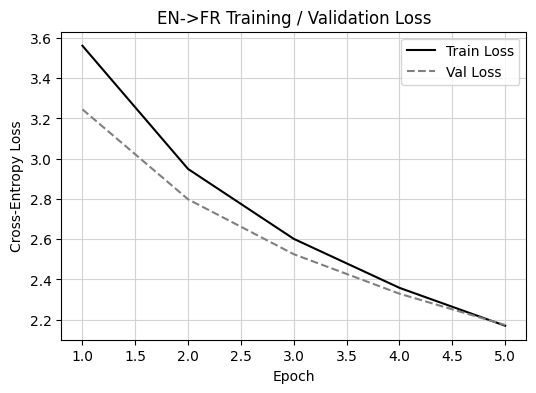

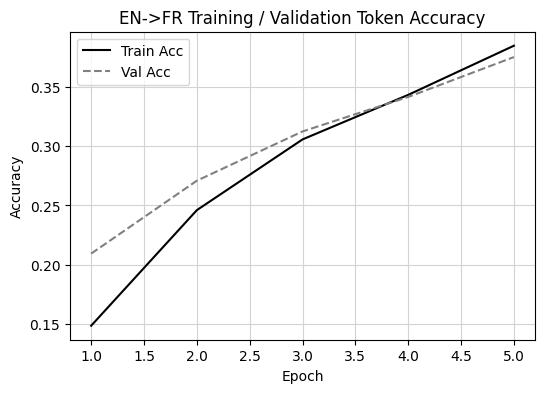

In [23]:
# ----------------------------------------------------------------------------
# 13. STANDARD EDUCATIONAL VISUALIZATIONS (individual plots)
# ----------------------------------------------------------------------------
epochs_range = list(range(1, N_EPOCHS + 1))

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", color="black")
ax1.plot(epochs_range, history["val_loss"], label="Val Loss", color="grey", linestyle="--")
ax1.set_title("EN->FR Training / Validation Loss", color="black")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.grid(True, color="lightgrey")

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_acc"], label="Train Acc", color="black")
ax2.plot(epochs_range, history["val_acc"], label="Val Acc", color="grey", linestyle="--")
ax2.set_title("EN->FR Training / Validation Token Accuracy", color="black")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(True, color="lightgrey")

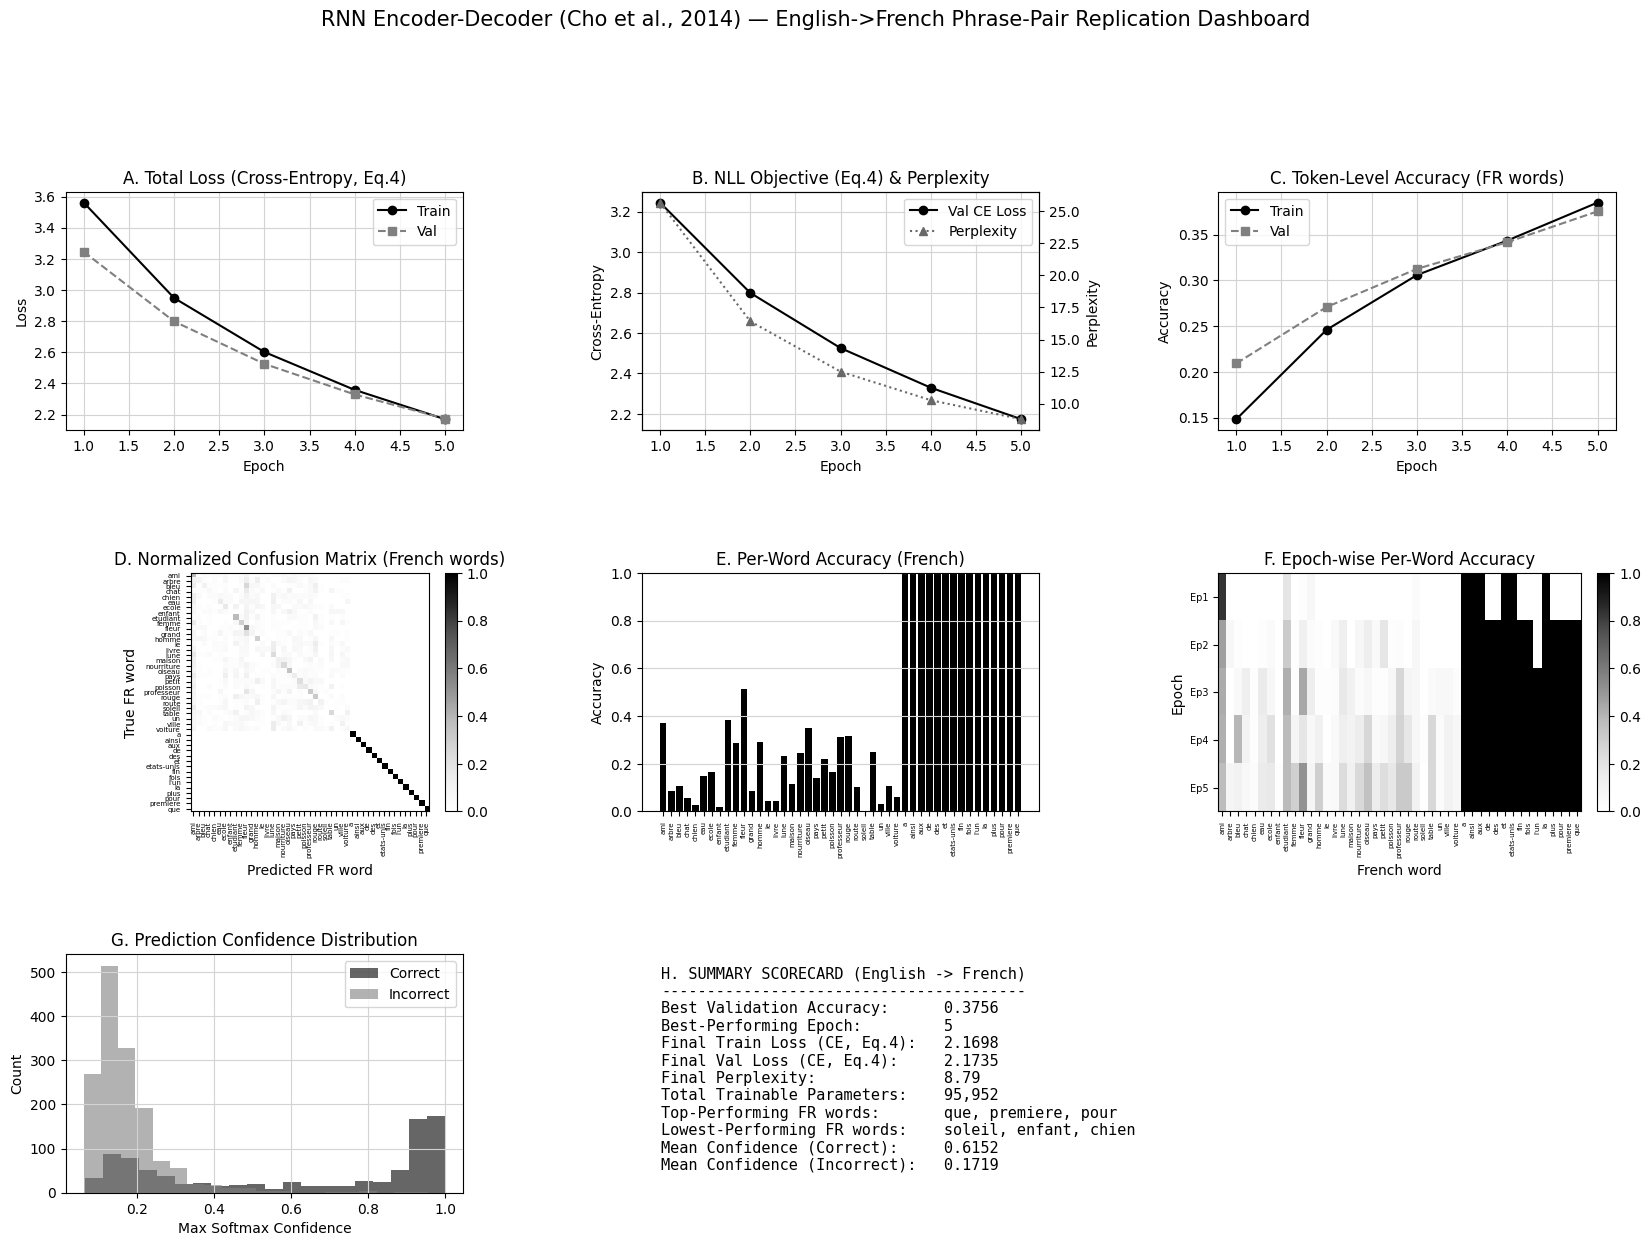

In [24]:
# ----------------------------------------------------------------------------
# 14. FINAL MULTI-PANEL SUMMARY DASHBOARD (3 rows, Panels A-H)
#     Rendered to an in-memory buffer and displayed inline (Colab-safe).
# ----------------------------------------------------------------------------
dash_fig = plt.figure(figsize=(20, 13), facecolor="white")
gs = GridSpec(3, 3, figure=dash_fig, hspace=0.6, wspace=0.45)

def style_axis(ax):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(colors="black")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# --- Panel A: Total training/validation loss ---
axA = dash_fig.add_subplot(gs[0, 0]); style_axis(axA)
axA.plot(epochs_range, history["train_loss"], color="black", marker="o", label="Train")
axA.plot(epochs_range, history["val_loss"], color="grey", marker="s", linestyle="--", label="Val")
axA.set_title("A. Total Loss (Cross-Entropy, Eq.4)")
axA.set_xlabel("Epoch"); axA.set_ylabel("Loss")
axA.legend(facecolor="white", labelcolor="black")
axA.grid(True, color="lightgrey")

# --- Panel B: Paper-specific loss components (the paper defines a single
#     unified conditional-likelihood objective, Eq.4; here decomposed into
#     the Cross-Entropy loss and its derived Perplexity for interpretability) ---
axB = dash_fig.add_subplot(gs[0, 1]); style_axis(axB)
axB.plot(epochs_range, history["val_loss"], color="black", marker="o", label="Val CE Loss")
axB2 = axB.twinx()
axB2.plot(epochs_range, history["perplexity"], color="dimgrey", marker="^", linestyle=":", label="Perplexity")
axB2.tick_params(colors="black")
axB2.set_ylabel("Perplexity", color="black")
axB.set_title("B. NLL Objective (Eq.4) & Perplexity")
axB.set_xlabel("Epoch"); axB.set_ylabel("Cross-Entropy")
lines1, labels1 = axB.get_legend_handles_labels()
lines2, labels2 = axB2.get_legend_handles_labels()
axB.legend(lines1 + lines2, labels1 + labels2, facecolor="white", labelcolor="black", loc="upper right")
axB.grid(True, color="lightgrey")

# --- Panel C: Training/Validation token accuracy ---
axC = dash_fig.add_subplot(gs[0, 2]); style_axis(axC)
axC.plot(epochs_range, history["train_acc"], color="black", marker="o", label="Train")
axC.plot(epochs_range, history["val_acc"], color="grey", marker="s", linestyle="--", label="Val")
axC.set_title("C. Token-Level Accuracy (FR words)")
axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy")
axC.legend(facecolor="white", labelcolor="black")
axC.grid(True, color="lightgrey")

# --- Panel D: Normalized confusion matrix over French target words ---
axD = dash_fig.add_subplot(gs[1, 0]); style_axis(axD)
cm_norm = final_cm.astype(float) / np.clip(final_cm.sum(axis=1, keepdims=True), 1, None)
im = axD.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D. Normalized Confusion Matrix (French words)")
axD.set_xticks(range(N_CLASSES)); axD.set_yticks(range(N_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=5, color="black")
axD.set_yticklabels(CLASS_NAMES, fontsize=5, color="black")
axD.set_xlabel("Predicted FR word"); axD.set_ylabel("True FR word")
cbar = dash_fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# --- Panel E: Per-class (per French word) accuracy bar chart ---
axE = dash_fig.add_subplot(gs[1, 1]); style_axis(axE)
per_class_acc = per_class_accuracy_from_confmat(final_cm)
axE.bar(CLASS_NAMES, per_class_acc, color="black")
axE.set_title("E. Per-Word Accuracy (French)")
axE.set_ylabel("Accuracy"); axE.set_ylim(0, 1)
axE.tick_params(axis="x", rotation=90, labelsize=5)
axE.grid(True, axis="y", color="lightgrey")

# --- Panel F: Epoch-wise per-class accuracy heatmap ---
axF = dash_fig.add_subplot(gs[1, 2]); style_axis(axF)
heat = np.array(history["per_class_acc_by_epoch"])  # (epochs, classes)
im2 = axF.imshow(heat, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_title("F. Epoch-wise Per-Word Accuracy")
axF.set_xticks(range(N_CLASSES)); axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=5)
axF.set_yticks(range(N_EPOCHS)); axF.set_yticklabels([f"Ep{e}" for e in epochs_range], fontsize=7)
axF.set_xlabel("French word"); axF.set_ylabel("Epoch")
cbar2 = dash_fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# --- Panel G: Confidence distribution histogram (correct vs incorrect) ---
axG = dash_fig.add_subplot(gs[2, 0]); style_axis(axG)
axG.hist(all_conf_correct, bins=20, alpha=0.6, color="black", label="Correct")
axG.hist(all_conf_incorrect, bins=20, alpha=0.6, color="grey", label="Incorrect")
axG.set_title("G. Prediction Confidence Distribution")
axG.set_xlabel("Max Softmax Confidence"); axG.set_ylabel("Count")
axG.legend(facecolor="white", labelcolor="black")
axG.grid(True, color="lightgrey")

# --- Panel H: Text-based summary scorecard ---
axH = dash_fig.add_subplot(gs[2, 1:]); style_axis(axH)
axH.axis("off")

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])
top_classes_idx = np.argsort(per_class_acc)[::-1][:3]
low_classes_idx = np.argsort(per_class_acc)[:3]
top_classes = ", ".join(CLASS_NAMES[i] for i in top_classes_idx)
low_classes = ", ".join(CLASS_NAMES[i] for i in low_classes_idx)

scorecard_text = (
    "H. SUMMARY SCORECARD (English -> French)\n"
    "----------------------------------------\n"
    f"Best Validation Accuracy:      {best_val_acc:.4f}\n"
    f"Best-Performing Epoch:         {best_epoch}\n"
    f"Final Train Loss (CE, Eq.4):   {history['train_loss'][-1]:.4f}\n"
    f"Final Val Loss (CE, Eq.4):     {history['val_loss'][-1]:.4f}\n"
    f"Final Perplexity:              {history['perplexity'][-1]:.2f}\n"
    f"Total Trainable Parameters:    {total_params:,}\n"
    f"Top-Performing FR words:       {top_classes}\n"
    f"Lowest-Performing FR words:    {low_classes}\n"
    f"Mean Confidence (Correct):     {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect):   {mean_conf_incorrect:.4f}\n"
)
axH.text(0.02, 0.95, scorecard_text, transform=axH.transAxes,
          fontsize=11, va="top", ha="left", color="black", family="monospace")

dash_fig.suptitle(
    "RNN Encoder-Decoder (Cho et al., 2014) — English->French Phrase-Pair Replication Dashboard",
    color="black", fontsize=15, y=1.02
)

# --- Render to in-memory buffer and display inline (no savefig, no plt.show) ---
buf = io.BytesIO()
dash_fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close("all")